## 🔍 Explainability, Bias Analysis & Deployment

### 🔹 Purpose of this Notebook

This notebook explains model predictions using SHAP, evaluates fairness across groups, and prepares the model for deployment.

---

### 🔹 Objectives

* Interpret model predictions using SHAP
* Identify key features influencing fraud detection
* Evaluate model fairness across demographic groups
* Build a scoring script for real-world predictions


### Load the libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import pickle

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_recall_curve
)
plt.style.use('default')

# Load the artifacts

In [33]:
automl = joblib.load("fraud_automl_model.pkl")
X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")

print("Loaded model and test data")

Loaded model and test data


In [34]:
automl.best_estimator

'xgboost'

In [35]:
# Load encoder
with open("model_package/encoder.pkl", "rb") as f:
    encoder = pickle.load(f)

# Load threshold
with open("model_package/threshold.pkl", "rb") as f:
    threshold = pickle.load(f)

# Load column order
with open("model_package/columns.pkl", "rb") as f:
    features = pickle.load(f)

print("All artifacts loaded successfully")

All artifacts loaded successfully


# SHAP 

In [36]:
# SHAP EXPLAINER

model = automl.model.estimator

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed")

SHAP values computed


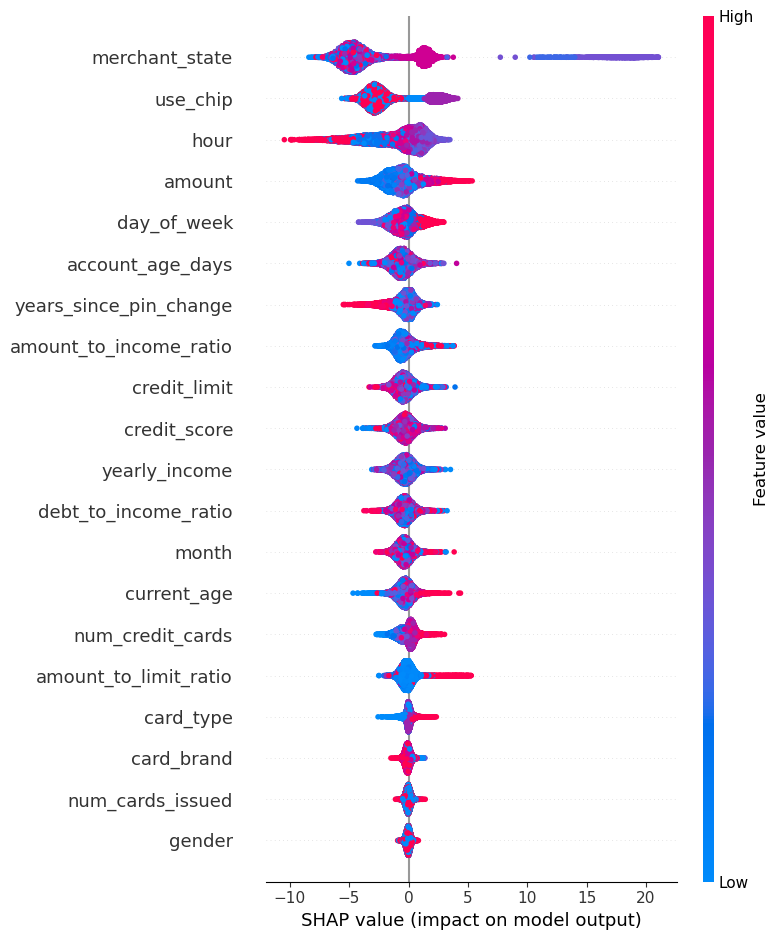

In [37]:
# SHAP SUMMARY PLOT

shap.summary_plot(shap_values, X_test)

**Interpretation:**

* SHAP analysis identifies the most important features affecting predictions
* Features such as merchant_state, hour, and amount have the highest impact
* Both feature value and direction influence fraud prediction
* This improves model transparency and interpretability 


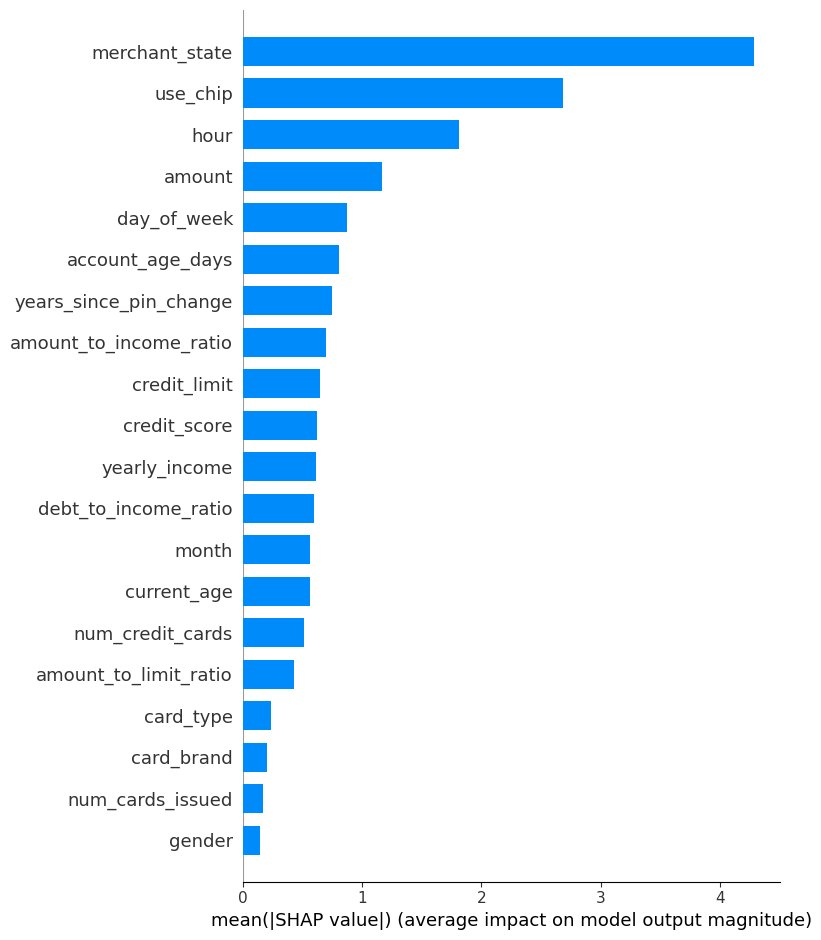

In [38]:
# bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Interpretation:**

* Year, merchant_state, and hour are the most influential features
* Transaction amount and ratio-based features also contribute significantly
* Model decisions are driven by both temporal and financial features 


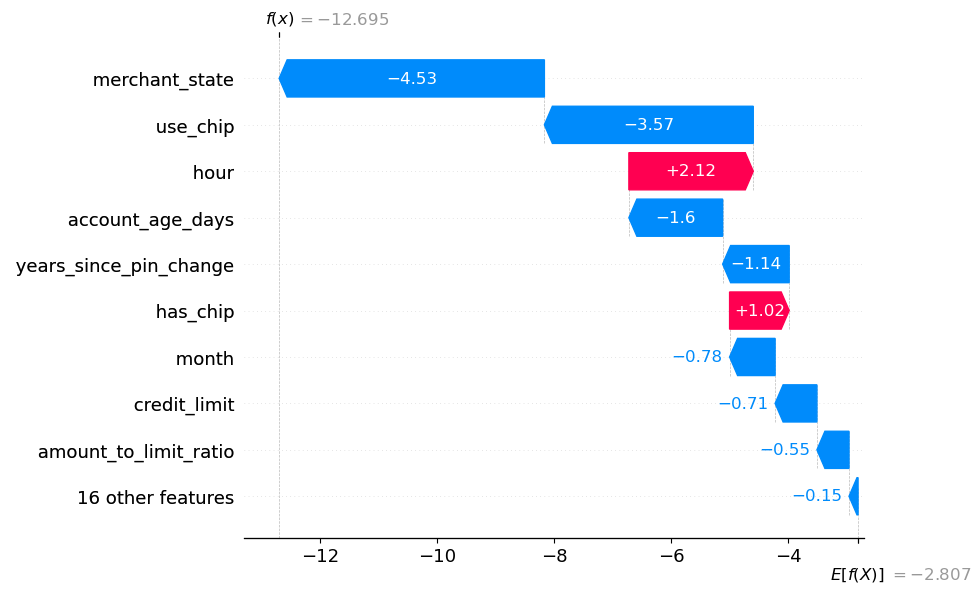

In [39]:
# First observation
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

**Interpretation:**

* Individual predictions can be explained using SHAP values
* Each feature contributes positively or negatively to the final prediction
* This allows understanding of why a specific transaction is classified as fraud


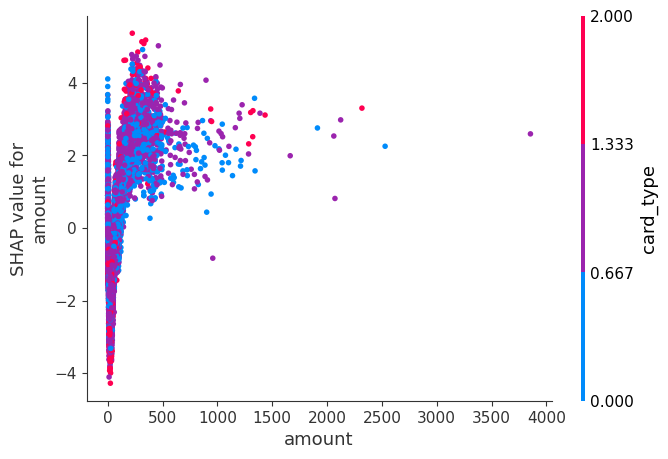

In [40]:
shap.dependence_plot("amount", shap_values, X_test)

**Interpretation:**

* Higher transaction amounts generally increase fraud probability
* Interaction with other features (e.g., income) affects the impact
* Confirms the importance of amount-related features


In [41]:
mean_shap = np.abs(shap_values).mean(axis=0)

feat_imp = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_shap
}).sort_values(by='Mean |SHAP|', ascending=False)

print("\nTop SHAP Features:")
print(feat_imp.head(10))


Top SHAP Features:
                   Feature  Mean |SHAP|
2           merchant_state     4.286229
1                 use_chip     2.685124
14                    hour     1.813652
0                   amount     1.167363
16             day_of_week     0.873360
18        account_age_days     0.807234
19  years_since_pin_change     0.746225
22  amount_to_income_ratio     0.697535
8             credit_limit     0.647619
12            credit_score     0.623629


# Bias Analysis

In [42]:
prob = automl.predict_proba(X_test)[:, 1]
pred = (prob >= threshold).astype(int)

In [43]:
# BIAS ANALYSIS — GENDER

df_eval = X_test.copy()
df_eval['actual'] = y_test
df_eval['pred'] = pred

print("\n=== BIAS CHECK: GENDER ===")

for g in df_eval['gender'].unique():
    subset = df_eval[df_eval['gender'] == g]

    rec = recall_score(subset['actual'], subset['pred'])
    print(f"{g}: Recall = {rec:.4f}")


=== BIAS CHECK: GENDER ===
0.0: Recall = 0.8859
1.0: Recall = 0.8946


**Interpretation:**

* Recall is similar across gender groups
* Difference is small (~1.8%)
* No significant bias detected in gender predictions 


In [46]:
df_eval_age = df_eval[df_eval['age_group'] >= 0]

for a in sorted(df_eval_age['age_group'].unique()):
    subset = df_eval_age[df_eval_age['age_group'] == a]
    if len(subset) == 0:
        continue
    rec = recall_score(subset['actual'], subset['pred'], zero_division=0)
    print(f"{int(a)}: Recall = {rec:.4f}")

0: Recall = 0.9000
1: Recall = 0.8476
2: Recall = 0.8743
3: Recall = 0.9027
4: Recall = 0.9060


**Interpretation:**

* Recall varies across age groups
* Overall, no strong bias observed, but results should be interpreted cautiously


# Deployment - Scoring Script

In [60]:
categorical_cols = [
    'use_chip',
    'merchant_state',
    'card_brand',
    'card_type',
    'gender',
    'age_group'
]

def preprocess_input(df):
    data = df.copy()

    # Ensure all required columns exist
    for col in features:
        if col not in data.columns:
            data[col] = "unknown"

    # Ensure correct order
    data = data[features]

    # Apply OrdinalEncoder
    data[categorical_cols] = encoder.transform(
        data[categorical_cols].astype(str)
    )

    return data



def predict_fraud(df):
    prob = model.predict_proba(df)[:, 1]
    pred = (prob >= threshold).astype(int)

    return pd.DataFrame({
        "fraud_probability": prob,
        "prediction": pred
    })

In [ ]:
scoring = """import pandas as pd
import pickle
import joblib

# Load artifacts
model = joblib.load("model_package/fraud_automl_model.pkl")

with open("model_package/columns.pkl", "rb") as f:
    features = pickle.load(f)

with open("model_package/threshold.pkl", "rb") as f:
    threshold = pickle.load(f)

with open("model_package/encoder.pkl", "rb") as f:
    encoder = pickle.load(f)

categorical_cols = [
    'use_chip',
    'merchant_state',
    'card_brand',
    'card_type',
    'gender',
    'age_group'
]

def preprocess_input(df):
    data = df.copy()

    for col in features:
        if col not in data.columns:
            data[col] = "unknown"

    data = data[features]

    data[categorical_cols] = encoder.transform(
        data[categorical_cols].astype(str)
    )

    return data


def predict_fraud(df):
    data = preprocess_input(df)

    prob = model.predict_proba(data)[:, 1]
    pred = (prob >= threshold).astype(int)

    return pd.DataFrame({
        "fraud_probability": prob,
        "prediction": pred
    })


if __name__ == "__main__":
    df = pd.read_csv("model_package/sample_data.csv")
    print(predict_fraud(df))
"""

In [63]:
with open("model_package/scoring_script.py", "w") as f:
    f.write(scoring)

print("Scoring script ready")

Scoring script ready


**Interpretation:**

* A scoring function was created to generate predictions on new data
* The model uses the same features and preprocessing as training
* Predictions include both probability and classification
* This enables real-world deployment of the model 


In [65]:
# def predict_fraud(df):
#     prob = model.predict_proba(df)[:, 1]
#     pred = (prob >= threshold).astype(int)

#     return pd.DataFrame({
#         "fraud_probability": prob,
#         "prediction": pred
#     })

In [66]:
result = predict_fraud(X_test[y_test == 1].head(5))
print(result)

   fraud_probability  prediction
0           0.041162           0
1           0.999999           1
2           0.989117           1
3           0.000138           0
4           0.999998           1


**Interpretation:**

* The scoring function was tested on sample data
* Predictions are generated correctly with probability and class output
* Confirms that the deployment pipeline is working as expected 


## 🔹 Key Insights

* SHAP analysis provides transparency into model decisions

* Temporal and financial features are most important for fraud detection

* The model shows no significant bias across gender and age groups

* A complete deployment pipeline has been created

* model is suitable for real-world fraud detection scenarios
